# Load data

In [34]:
import scipy.io
import numpy as np
mat = scipy.io.loadmat("Xtrain.mat")
y = mat["Xtrain"].squeeze().astype(np.float32)
print(y)

[ 86. 141.  95.  41.  22.  21.  32.  72. 138. 111.  48.  23.  19.  27.
  59. 129. 129.  58.  27.  19.  24.  46. 112. 144.  73.  30.  20.  19.
  37.  92. 152.  93.  36.  20.  18.  29.  71. 146. 117.  46.  23.  18.
  22.  52. 128. 142.  62.  26.  17.  19.  37. 100. 158.  86.  32.  17.
  17.  27.  72. 154. 118.  43.  20.  15.  21.  47. 128. 150.  63.  24.
  16.  17.  33.  92. 166.  95.  33.  16.  14.  22.  58. 149. 137.  50.
  20.  15.  16.  35. 106. 169.  82.  28.  15.  14.  23.  65. 160. 133.
  45.  18.  14.  16.  36. 111. 176.  80.  26.  14.  13.  20.  60. 163.
 140.  45.  18.  12.  14.  30.  98. 185.  93.  28.  14.  12.  17.  46.
 145. 167.  58.  19.  11.  12.  21.  68. 183. 132.  38.  15.  11.  13.
  26.  93. 202. 100.  27.  12.  10.  13.  30. 114. 206.  82.  21.  11.
   9.  10.  30. 120. 215.  77.  20.  10.   8.   9.  21.  95. 234.  99.
  22.   9.   8.   7.   9.  35. 176. 215.  46.  11.   7.   5.   4.   3.
   4.  19. 105. 125.  55.  30.  28.  41.  71.  98.  79.  49.  34.  33.
  47. 

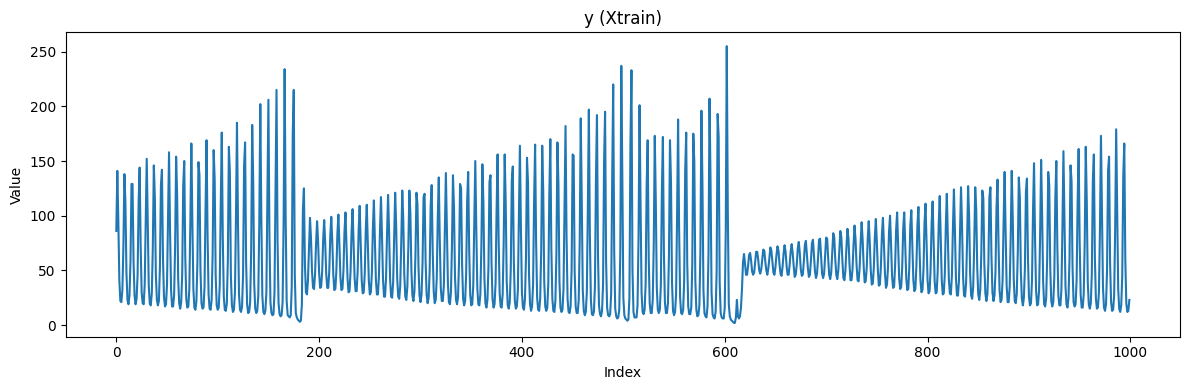

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(y)
plt.title("y (Xtrain)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

# Split data chronologically: train / tuning-validation


In [36]:
N = len(y)

train_end = int(0.80 * N)

y_train = y[:train_end]         
y_val_tune = y[train_end:]      


In [37]:
# Apply log transform first, then scale using train statistics only
y_train_log = np.log1p(y_train)
y_val_tune_log = np.log1p(y_val_tune)

mu = y_train_log.mean()
sigma = y_train_log.std()

y_train_scaled = (y_train_log - mu) / sigma
y_val_tune_scaled = (y_val_tune_log - mu) / sigma


In [38]:
def past_windows_parameter(y_scaled, p):
    X = []
    T = []

    for i in range(len(y_scaled) - p):
        X.append(y_scaled[i:i+p])
        T.append(y_scaled[i+p])

    X = np.array(X, dtype=np.float32)
    T = np.array(T, dtype=np.float32).reshape(-1, 1)

    return X, T

In [39]:
p = 10

X_train, T_train = past_windows_parameter(y_train_scaled, p)
X_val_tune, T_val_tune = past_windows_parameter(y_val_tune_scaled, p)

print("X_train:", X_train.shape)
print("T_train:", T_train.shape)
print("X_val_tune:", X_val_tune.shape)
print("T_val_tune:", T_val_tune.shape)


X_train: (790, 10)
T_train: (790, 1)
X_val_tune: (190, 10)
T_val_tune: (190, 1)


# convert to PyTorch tensors

In [40]:
import torch
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
T_train_tensor = torch.tensor(T_train, dtype=torch.float32)

X_val_tune_tensor = torch.tensor(X_val_tune, dtype=torch.float32)
T_val_tune_tensor = torch.tensor(T_val_tune, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, T_train_tensor)
val_tune_dataset = TensorDataset(X_val_tune_tensor, T_val_tune_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_tune_dataset, batch_size=32, shuffle=False)


# Nonlinear MLP model 


In [41]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(p, 32),
    nn.Tanh(),
    nn.Linear(32, 1)
)


# Train

In [42]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs = 200
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    model.train()
    batch_losses = []
    for X_batch, T_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), T_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_batch, T_batch in val_loader:
            val_batch_losses.append(criterion(model(X_batch), T_batch).item())
    val_losses.append(np.mean(val_batch_losses))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}")

Epoch 50/200  train=0.0206  val=0.0035
Epoch 100/200  train=0.0116  val=0.0036
Epoch 150/200  train=0.0099  val=0.0029
Epoch 200/200  train=0.0088  val=0.0034


# Loss curves

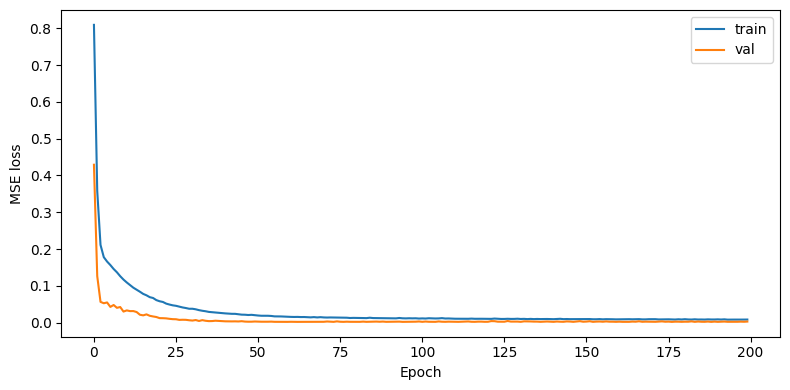

In [43]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.show()

# Predictions

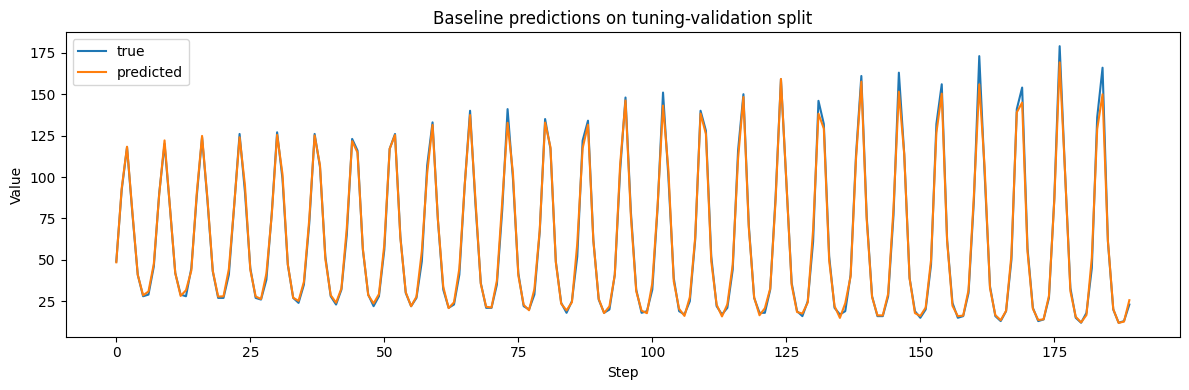

Tuning-val MSE: 10.38


In [44]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_val_tune_tensor).numpy().squeeze()

y_pred_log = y_pred_scaled * sigma + mu
y_true_log = T_val_tune.squeeze() * sigma + mu

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

plt.figure(figsize=(12, 4))
plt.plot(y_true, label="true")
plt.plot(y_pred, label="predicted")
plt.xlabel("Step")
plt.ylabel("Value")
plt.title("Baseline predictions on tuning-validation split")
plt.legend()
plt.tight_layout()
plt.show()

mse = np.mean((y_pred - y_true) ** 2)
print(f"Tuning-val MSE: {mse:.2f}")


# Tune p 

In [45]:
p_values = [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
p_val_mse = []
p_best_epochs = []

for p_cand in p_values:
    X_tr, T_tr = past_windows_parameter(y_train_scaled, p_cand)

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    T_tr_t = torch.tensor(T_tr, dtype=torch.float32)

    loader = DataLoader(TensorDataset(X_tr_t, T_tr_t), batch_size=32, shuffle=True)

    torch.manual_seed(42)
    np.random.seed(42)
    m = nn.Sequential(nn.Linear(p_cand, 32), nn.Tanh(), nn.Linear(32, 1))
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    best_recursive_mse = np.inf
    best_epoch = 0

    for epoch in range(200):
        m.train()
        for xb, tb in loader:
            opt.zero_grad()
            loss_fn(m(xb), tb).backward()
            opt.step()

        window = list(y_train_scaled[-p_cand:])
        recursive_preds_scaled = []

        m.eval()
        with torch.no_grad():
            for _ in range(len(y_val_tune)):
                x = torch.tensor(window[-p_cand:], dtype=torch.float32).unsqueeze(0)
                next_val = m(x).item()
                recursive_preds_scaled.append(next_val)
                window.append(next_val)

        recursive_preds_log = np.array(recursive_preds_scaled) * sigma + mu
        recursive_preds = np.expm1(recursive_preds_log)
        recursive_mse = np.mean((recursive_preds - y_val_tune) ** 2)

        if recursive_mse < best_recursive_mse:
            best_recursive_mse = recursive_mse
            best_epoch = epoch + 1

    p_val_mse.append(best_recursive_mse)
    p_best_epochs.append(best_epoch)
    print(f"p={p_cand:2d}  recursive tuning val MSE={best_recursive_mse:.4f}  best epoch={best_epoch}")

best_idx = np.argmin(p_val_mse)
best_p = p_values[best_idx]
best_epoch = p_best_epochs[best_idx]
print(f"\nBest p: {best_p}")
print(f"Best epoch: {best_epoch}")


p= 2  recursive tuning val MSE=351.9063  best epoch=155
p= 5  recursive tuning val MSE=1093.4791  best epoch=91
p=10  recursive tuning val MSE=1568.5079  best epoch=160
p=15  recursive tuning val MSE=34.9012  best epoch=88
p=20  recursive tuning val MSE=478.0405  best epoch=95
p=25  recursive tuning val MSE=106.4500  best epoch=176
p=30  recursive tuning val MSE=2055.9800  best epoch=17
p=35  recursive tuning val MSE=988.7947  best epoch=133
p=40  recursive tuning val MSE=740.9913  best epoch=170
p=45  recursive tuning val MSE=1223.7333  best epoch=154
p=50  recursive tuning val MSE=572.0993  best epoch=191

Best p: 15
Best epoch: 88


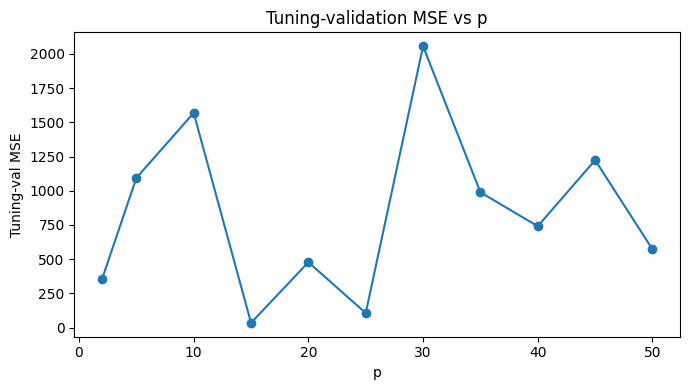

In [46]:
plt.figure(figsize=(7, 4))
plt.plot(p_values, p_val_mse, marker="o")
plt.xlabel("p")
plt.ylabel("Tuning-val MSE")
plt.title("Tuning-validation MSE vs p")
plt.tight_layout()
plt.show()


# Retrain with best p


Epoch 50/88  train=0.0117


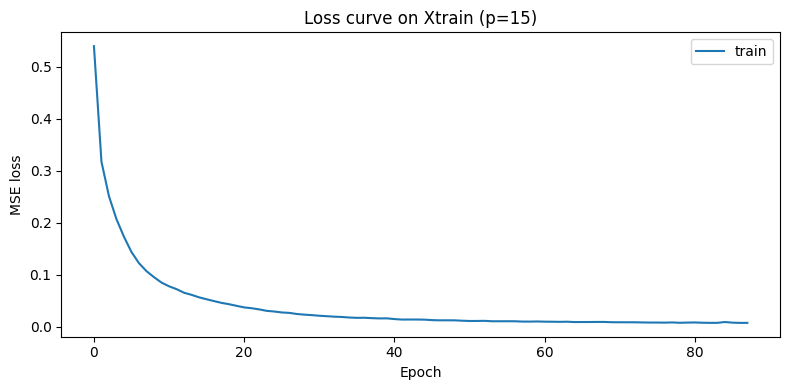

In [47]:
p = best_p

y_train_final = y
y_train_final_log = np.log1p(y_train_final)
y_train_final_scaled = (y_train_final_log - mu) / sigma

X_train_final, T_train_final = past_windows_parameter(y_train_final_scaled, p)

X_train_final_tensor = torch.tensor(X_train_final, dtype=torch.float32)
T_train_final_tensor = torch.tensor(T_train_final, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_final_tensor, T_train_final_tensor), batch_size=32, shuffle=True)

torch.manual_seed(42)
np.random.seed(42)
model = nn.Sequential(nn.Linear(p, 32), nn.Tanh(), nn.Linear(32, 1))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs = best_epoch
train_losses = []

for epoch in range(n_epochs):
    model.train()
    batch_losses = []
    for X_batch, T_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), T_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}  train={train_losses[-1]:.4f}")

# loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title(f"Loss curve on Xtrain (p={p})")
plt.legend()
plt.tight_layout()
plt.show()


# Recursive 200-step prediction

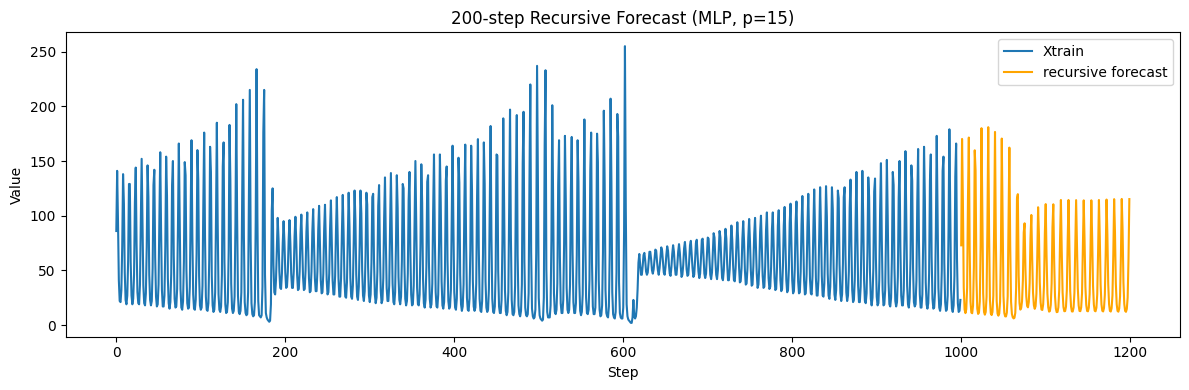

In [51]:
window = list(y_train_final_scaled[-p:])

model.eval()
recursive_preds_scaled = []

with torch.no_grad():
    for _ in range(200):
        x = torch.tensor(window[-p:], dtype=torch.float32).unsqueeze(0)
        next_val = model(x).item()
        recursive_preds_scaled.append(next_val)
        window.append(next_val)

recursive_preds_log = np.array(recursive_preds_scaled) * sigma + mu
recursive_preds = np.expm1(recursive_preds_log)

plt.figure(figsize=(12, 4))
plt.plot(range(len(y_train_final)), y_train_final, label="Xtrain")
plt.plot(range(len(y_train_final), len(y_train_final) + 200), recursive_preds, label="recursive forecast", color="orange")
plt.xlabel("Step")
plt.ylabel("Value")
plt.title(f"200-step Recursive Forecast (MLP, p={p})")
plt.legend()
plt.tight_layout()
plt.show()


# run on test set

In [49]:
# evaluate recursive forecast on test set

# Load test data 
mat_test = scipy.io.loadmat("Xtest.mat")
y_test = mat_test["Xtest"].squeeze().astype(np.float32)

# Prepare recursive rollout from end of Xtrain
window = list(y_train_final_scaled[-p:])

horizon = min(200, len(y_test))
recursive_preds_scaled = []

model.eval()
with torch.no_grad():
    for _ in range(horizon):
        x = torch.tensor(window[-p:], dtype=torch.float32).unsqueeze(0)  # shape (1, p)
        next_val = model(x).item()
        recursive_preds_scaled.append(next_val)
        window.append(next_val)

recursive_preds_log = np.array(recursive_preds_scaled, dtype=np.float32) * sigma_final + mu_final
recursive_preds = np.expm1(recursive_preds_log)
y_true = y_test[:horizon]

# Metrics
mse = np.mean((recursive_preds - y_true) ** 2)
mae = np.mean(np.abs(recursive_preds - y_true))
print(f"Test Recursive {horizon}: step MSE: {mse:.4f}")
print(f"Test Recursive {horizon}: step MAE: {mae:.4f}")

# Plot predicted vs real test values
plt.figure(figsize=(12, 4))
plt.plot(y_true, label="real test", linewidth=2)
plt.plot(recursive_preds, label="recursive prediction", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Value")
plt.title(f"Recursive Forecast vs Real Test")
plt.legend()
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'Xtest.mat'